In [3]:
import pandas as pd

In [4]:
path = r"E:\Semester9\ACL\M1\AirlineScrappedReview_Cleaned_seif_we_ibra#1.csv"
asr=pd.read_csv(path)

In [5]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5),

# Binary Classification Model for Passenger Satisfaction

## Objective
Predict passenger satisfaction based on:
- **Traveller-related features**: Type and Class
- **Flight features**: Route, locations, layovers
- **Review features**: Verified status and sentiment score
- **Target**: Satisfied (Rating >= 5) vs Dissatisfied (Rating < 5)

## Step 1: Data Exploration and Preparation

In [6]:
# Display first few rows
print("Dataset shape:", asr.shape)
print("\nFirst few rows:")
asr.head()

Dataset shape: (2807, 17)

First few rows:


,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
0,Paige Boet,New Orleans to London,1.0,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
1,S Layne,London to Amman,1.0,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,..."
2,E Lanewoski,Heathrow to Bodrum,2.0,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye"
3,Joel Burman,Amman to London,4.0,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,NaN,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom"
4,R Vines,London City to Ibiza,7.0,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,NaN,42.953765,-81.229153,"London City Airport, Connaught Road, Silvertow...",38.974390,1.419746,"Eivissa, Illes Balears, España"


In [7]:
# Check for missing values and basic statistics
print("Missing values per column:")
print(asr.isnull().sum())
print("\n" + "="*50)
print("\nRating distribution:")
print(asr['Rating'].describe())

Missing values per column:
Passanger_Name        0
Route                 0
Rating                0
Verified              0
Review_title          0
Review_content        0
Traveller_Type        0
Class                 0
Start_Location        0
End_Location          0
Layover_Route      2323
Start_Latitude       60
Start_Longitude      60
Start_Address         0
End_Latitude         99
End_Longitude        99
End_Address           0
dtype: int64


Rating distribution:
count    2807.000000
mean        4.475240
std         3.118132
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        10.000000
Name: Rating, dtype: float64


In [8]:
# Check unique values for categorical features
print("Unique values in categorical columns:")
print(f"Traveller_Type: {asr['Traveller_Type'].unique()}")
print(f"Class: {asr['Class'].unique()}")
print(f"Verified: {asr['Verified'].unique()}")
print(f"\nValue counts for Traveller_Type:")
print(asr['Traveller_Type'].value_counts())
print(f"\nValue counts for Class:")
print(asr['Class'].value_counts())

Unique values in categorical columns:
Traveller_Type: ['Solo Leisure' 'Couple Leisure' 'Family Leisure' 'Business' 'Unknown'
 'Various']
Class: ['Economy Class' 'Business Class' 'Premium Economy' 'First Class'
 'Unknown']
Verified: ['Trip Verified' 'Not Verified']

Value counts for Traveller_Type:
Traveller_Type
Couple Leisure    945
Solo Leisure      860
Business          622
Family Leisure    377
Unknown             2
Various             1
Name: count, dtype: int64

Value counts for Class:
Class
Economy Class      1518
Business Class      863
Premium Economy     270
First Class         155
Unknown               1
Name: count, dtype: int64


## Data Preprocessing Pipeline

This section will:
1. Standardize the Route column (convert "to" → "-")
2. Check for and handle duplicate rows
3. Calculate sentiment scores using VADER
4. Export the cleaned data to a new Excel file

### Step 1: Standardize Route Column

In [30]:
# Standardize Route column - replace "to" with "-"
import re

def standardize_route(route):
    """
    Standardize route format to use '-' separator
    Handles: 'City to City', 'City  to  City', etc.
    """
    if pd.isna(route):
        return route
    
    # Convert to string
    route_str = str(route)
    
    # Replace ' to ' (with any amount of spaces) with '-'
    # Case insensitive replacement
    route_standardized = re.sub(r'\s+to\s+', '-', route_str, flags=re.IGNORECASE)
    
    # Clean up multiple spaces
    route_standardized = re.sub(r'\s+', ' ', route_standardized)
    
    # Strip leading/trailing spaces
    route_standardized = route_standardized.strip()
    
    return route_standardized

# Create a copy of the dataframe to preserve original
asr_processed = asr.copy()

# Apply standardization
print("=" * 60)
print("STEP 1: STANDARDIZING ROUTE COLUMN")
print("=" * 60)
print(f"\nOriginal unique routes: {asr_processed['Route'].nunique()}")

asr_processed['Route'] = asr_processed['Route'].apply(standardize_route)

print(f"After standardization: {asr_processed['Route'].nunique()}")
print(f"Routes consolidated: {asr['Route'].nunique() - asr_processed['Route'].nunique()}")

print("\nSample of standardized routes:")
print(asr_processed['Route'].head(10))

STEP 1: STANDARDIZING ROUTE COLUMN

Original unique routes: 1005
After standardization: 930
Routes consolidated: 75

Sample of standardized routes:
0            MSY-LHR
1            LHR-AMM
2            LHR-BJV
3            AMM-LHR
4            LHR-IBZ
5            LHR-SEA
6            AMS-LHR
7            LHR-KLX
8            LHR-FNC
9    MRS-SEA via LHR
Name: Route, dtype: object


### Step 2: Check for Duplicate/Common Rows

In [31]:
# Check for duplicate rows
print("=" * 60)
print("STEP 2: CHECKING FOR DUPLICATE ROWS")
print("=" * 60)

# Check for exact duplicates
print(f"\nTotal rows: {len(asr_processed)}")
print(f"Duplicate rows (all columns): {asr_processed.duplicated().sum()}")

# Check for duplicates based on key columns (excluding Passanger_Name which might differ)
key_columns = ['Route', 'Rating', 'Review_content', 'Traveller_Type', 'Class', 'Verified']
duplicates_key = asr_processed.duplicated(subset=key_columns, keep=False)
print(f"Duplicate rows (key columns only): {duplicates_key.sum()}")

# Show some duplicate examples if they exist
if duplicates_key.sum() > 0:
    print("\nSample of duplicate rows:")
    duplicate_samples = asr_processed[duplicates_key].sort_values(by=key_columns).head(10)
    print(duplicate_samples[key_columns])
    
    # Ask what to do with duplicates
    print("\n" + "=" * 60)
    print("Note: Keeping all rows for now. You can remove duplicates if needed.")
    print("=" * 60)
else:
    print("\n✅ No duplicate rows found!")

# Show data shape
print(f"\nCurrent dataset shape: {asr_processed.shape}")

STEP 2: CHECKING FOR DUPLICATE ROWS

Total rows: 2807
Duplicate rows (all columns): 0
Duplicate rows (key columns only): 0

✅ No duplicate rows found!

Current dataset shape: (2807, 22)


### Step 3: Calculate Sentiment Scores using VADER

In [32]:
# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr_processed['Sentiment_Score'] = asr_processed['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr_processed['Sentiment_Score'].describe())

print(f"\nSample reviews with sentiment scores:")
sample_display = asr_processed[['Review_content', 'Sentiment_Score', 'Rating']].head(10)
for idx, row in sample_display.iterrows():
    print(f"\nRating: {row['Rating']:.1f} | Sentiment: {row['Sentiment_Score']:.3f}")
    print(f"Review: {row['Review_content'][:100]}...")

✅ VADER lexicon ready!

STEP 3: CALCULATING SENTIMENT SCORES

Calculating sentiment scores using VADER...
✅ Sentiment scores calculated!

Sentiment Score Statistics:
count    2807.000000
mean        0.125478
std         0.781512
min        -0.997400
25%        -0.765000
50%         0.361200
75%         0.918450
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample reviews with sentiment scores:

Rating: 1.0 | Sentiment: -0.799
Review: The airline lost my luggage and was absolutely awful throughout the entire trip. They gave me no upd...

Rating: 1.0 | Sentiment: 0.718
Review: We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Busi...

Rating: 2.0 | Sentiment: -0.710
Review: First time flying with BA business class, never again. There are no boarding drinks provided. My mea...

Rating: 4.0 | Sentiment: -0.585
Review: You can buy sandwiches and crisps but don't expect a hot meal. Because the plane is a narrow body , ...

Rating: 7

### Step 4: Export Processed Data to Excel

In [34]:
# Install openpyxl for Excel export
%pip install openpyxl -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
# Export processed data to Excel
print("=" * 60)
print("STEP 4: EXPORTING PROCESSED DATA TO EXCEL")
print("=" * 60)

# Define output file path
output_path = r"E:\Semester9\ACL\M1\AirlineScrappedReview_Processed.xlsx"

print(f"\nExporting to: {output_path}")
print(f"Total rows: {len(asr_processed)}")
print(f"Total columns: {len(asr_processed.columns)}")

# Export to Excel
try:
    asr_processed.to_excel(output_path, index=False, engine='openpyxl')
    print("\n✅ SUCCESS! File exported successfully!")
    
    print("\n" + "=" * 60)
    print("SUMMARY OF PROCESSED DATA")
    print("=" * 60)
    print(f"\n✅ Route standardized: 'to' → '-'")
    print(f"✅ Duplicates checked")
    print(f"✅ Sentiment scores calculated (VADER)")
    print(f"✅ New column added: 'Sentiment_Score'")
    print(f"\n📁 Output file: {output_path}")
    print(f"📊 Rows: {len(asr_processed)}")
    print(f"📋 Columns: {len(asr_processed.columns)}")
    
    print("\nColumns in the exported file:")
    for i, col in enumerate(asr_processed.columns, 1):
        print(f"  {i}. {col}")
        
except Exception as e:
    print(f"\n❌ Error exporting file: {e}")
    print("\nTrying CSV export as backup...")
    csv_path = r"E:\Semester9\ACL\M1\AirlineScrappedReview_Processed.csv"
    asr_processed.to_csv(csv_path, index=False)
    print(f"✅ CSV file exported: {csv_path}")

STEP 4: EXPORTING PROCESSED DATA TO EXCEL

Exporting to: E:\Semester9\ACL\M1\AirlineScrappedReview_Processed.xlsx
Total rows: 2807
Total columns: 22

✅ SUCCESS! File exported successfully!

SUMMARY OF PROCESSED DATA

✅ Route standardized: 'to' → '-'
✅ Duplicates checked
✅ Sentiment scores calculated (VADER)
✅ New column added: 'Sentiment_Score'

📁 Output file: E:\Semester9\ACL\M1\AirlineScrappedReview_Processed.xlsx
📊 Rows: 2807
📋 Columns: 22

Columns in the exported file:
  1. Passanger_Name
  2. Route
  3. Rating
  4. Verified
  5. Review_title
  6. Review_content
  7. Traveller_Type
  8. Class
  9. Start_Location
  10. End_Location
  11. Layover_Route
  12. Start_Latitude
  13. Start_Longitude
  14. Start_Address
  15. End_Latitude
  16. End_Longitude
  17. End_Address
  18. Sentiment_Score
  19. Satisfaction
  20. Has_Layover
  21. Route_Standardized
  22. Route_Frequency


In [36]:
# Display final processed data preview
print("\n" + "=" * 60)
print("PREVIEW OF PROCESSED DATA")
print("=" * 60)

print("\nFirst 5 rows:")
display(asr_processed.head())

print("\nData info:")
asr_processed.info()


PREVIEW OF PROCESSED DATA

First 5 rows:


,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,...,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address,Sentiment_Score,Satisfaction,Has_Layover,Route_Standardized,Route_Frequency
0,Paige Boet,MSY-LHR,1.0,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,...,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom",-0.7990,0,0,New Orleans-London,3
1,S Layne,LHR-AMM,1.0,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,...,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",0.7184,0,0,London-Amman,2
2,E Lanewoski,LHR-BJV,2.0,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,...,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye",-0.7096,0,0,Heathrow-Bodrum,1
3,Joel Burman,AMM-LHR,4.0,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,...,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom",-0.5849,0,0,Amman-London,4
4,R Vines,LHR-IBZ,7.0,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,...,-81.229153,"London City Airport, Connaught Road, Silvertow...",38.974390,1.419746,"Eivissa, Illes Balears, España",0.9657,1,0,London City-Ibiza,2



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2807 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64

## ✅ Preprocessing Complete!

### What Was Done:

1. **✅ Route Standardization**
   - Converted all "City1 to City2" → "City1-City2"
   - Consolidated 75 duplicate route variations
   - Reduced unique routes from 1,005 → 930

2. **✅ Duplicate Check**
   - Checked for duplicate rows (both exact and key columns)
   - Result: No duplicates found in the dataset

3. **✅ Sentiment Analysis**
   - Applied VADER sentiment analysis on all reviews
   - Created `Sentiment_Score` column (range: -1 to +1)
   - Compound score captures overall sentiment intensity

4. **✅ Additional Features Created**
   - `Satisfaction`: Binary target (1 if Rating ≥ 5, else 0)
   - `Has_Layover`: Binary indicator for layover flights
   - `Route_Standardized`: Cleaned route format
   - `Route_Frequency`: Frequency encoding of routes

5. **✅ Excel Export**
   - **File**: `AirlineScrappedReview_Processed.xlsx`
   - **Location**: `E:\Semester9\ACL\M1\`
   - **Rows**: 2,807
   - **Columns**: 22 (original 17 + 5 new features)

### Next Steps:
You can now use this processed file for:
- Machine Learning model training (Random Forest, Neural Networks)
- Further analysis and visualization
- Feature engineering for classification tasks

In [23]:
# Explore Route column patterns
print("Sample Route values:")
print(asr['Route'].head(20))
print(f"\nTotal unique routes: {asr['Route'].nunique()}")
print(f"\nRoutes containing 'to': {asr['Route'].str.contains(' to ', case=False, na=False).sum()}")
print(f"Routes containing '-': {asr['Route'].str.contains('-', na=False).sum()}")
print(f"\nSample routes with 'to':")
print(asr[asr['Route'].str.contains(' to ', case=False, na=False)]['Route'].head(10))

Sample Route values:
0                        New Orleans to London
1                              London to Amman
2                           Heathrow to Bodrum
3                              Amman to London
4                         London City to Ibiza
5                         London to Washington
6                          Amsterdam to London
7                  London Heathrow to Kalamata
8                           London to Funchal 
9     Marseille to Seattle via London Heathrow
10                            Cairo to London 
11              Bucharest to Dallas via London
12                           Gatwick to Venice
13                       Dublin to London City
14            Tokyo to Manchester via Heathrow
15                     San Francisco to London
16                          Santiago to London
17                  Seattle to Nice via London
18    Sydney via Singapore to London Heathrow 
19           Seattle to Edinburgh via Heathrow
Name: Route, dtype: object

Total uniqu

### Standardizing Route Column
We need to standardize the Route format to ensure consistency:
- Convert all variations like "City1 to City2" to "City1-City2"
- Handle different separators and formats
- This will help with encoding and reduce the number of unique values

In [24]:
# Standardize Route column - replace "to" with "-"
import re

def standardize_route(route):
    """
    Standardize route format to use '-' separator
    Handles: 'City to City', 'City  to  City', etc.
    """
    if pd.isna(route):
        return route
    
    # Convert to string
    route_str = str(route)
    
    # Replace ' to ' (with any amount of spaces) with '-'
    # Case insensitive replacement
    route_standardized = re.sub(r'\s+to\s+', '-', route_str, flags=re.IGNORECASE)
    
    # Clean up multiple spaces
    route_standardized = re.sub(r'\s+', ' ', route_standardized)
    
    # Strip leading/trailing spaces
    route_standardized = route_standardized.strip()
    
    return route_standardized

# Apply standardization
print("Standardizing Route column...")
asr['Route_Standardized'] = asr['Route'].apply(standardize_route)

print("\nBefore standardization - Sample routes:")
print(asr['Route'].head(10).tolist())
print("\nAfter standardization - Sample routes:")
print(asr['Route_Standardized'].head(10).tolist())

print(f"\nUnique routes before: {asr['Route'].nunique()}")
print(f"Unique routes after: {asr['Route_Standardized'].nunique()}")

Standardizing Route column...

Before standardization - Sample routes:
['New Orleans to London', 'London to Amman', 'Heathrow to Bodrum', 'Amman to London', 'London City to Ibiza', 'London to Washington', 'Amsterdam to London', 'London Heathrow to Kalamata', 'London to Funchal ', 'Marseille to Seattle via London Heathrow']

After standardization - Sample routes:
['New Orleans-London', 'London-Amman', 'Heathrow-Bodrum', 'Amman-London', 'London City-Ibiza', 'London-Washington', 'Amsterdam-London', 'London Heathrow-Kalamata', 'London-Funchal', 'Marseille-Seattle via London Heathrow']

Unique routes before: 1541
Unique routes after: 1482


In [25]:
# Verify the standardization worked
print("Routes that still contain 'to' (should be 0 or very few):")
routes_with_to = asr[asr['Route_Standardized'].str.contains(' to ', case=False, na=False)]
print(f"Count: {len(routes_with_to)}")
if len(routes_with_to) > 0:
    print(routes_with_to['Route_Standardized'].head())

print(f"\nTop 20 most common routes after standardization:")
print(asr['Route_Standardized'].value_counts().head(20))

Routes that still contain 'to' (should be 0 or very few):
Count: 0

Top 20 most common routes after standardization:
Route_Standardized
London-Johannesburg     18
London-Cape Town        15
Johannesburg-London     15
Vancouver-London        13
BKK-LHR                 13
CPT-London              13
LHR-MIA                 12
Hong Kong-London        11
London-Athens           11
London-Vancouver        11
London-Hong Kong        11
LHR-BKK                 10
London-Dubai            10
JFK-LHR                 10
San Francisco-London     9
London-Boston            9
Singapore-London         9
London-Toronto           9
LHR-JFK                  9
LHR-CPT                  9
Name: count, dtype: int64


### Encoding Route for Machine Learning

We have several options for encoding the Route feature:

1. **Label Encoding**: Assigns a unique integer to each route (simple but assumes ordinal relationship)
2. **Frequency Encoding**: Replace routes with their frequency count
3. **Target Encoding**: Replace routes with the mean target value for that route
4. **Top-N + Other**: Keep top N most frequent routes, group rest as "Other"

We'll use **Frequency Encoding** because:
- Reduces dimensionality (single numeric feature)
- Popular routes get higher values (meaningful pattern)
- Handles unseen routes better than label encoding
- No data leakage unlike target encoding

In [29]:
asr['Route'] = asr['Route'].str.replace('Johannesburg', 'JNB')
asr['Route'] = asr['Route'].str.replace('Cape Town', 'CPT')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('London Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('Hong Kong', 'HKG')
asr['Route'] = asr['Route'].str.replace(' to San Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace('San Francisco to ', ' SFO to')
asr['Route'] = asr['Route'].str.replace('Rotterdam', 'RTM')
asr['Route'] = asr['Route'].str.replace('Muscat', 'MCT')
asr['Route'] = asr['Route'].str.replace('Lisbon', 'LIS')
asr['Route'] = asr['Route'].str.replace('London UK (Heathrow)', 'LHR')
asr['Route'] = asr['Route'].str.replace('London-Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace(' via Heathrow', ' via LHR')
asr['Route'] = asr['Route'].str.replace(' to Heathrow', ' to LHR')
asr['Route'] = asr['Route'].str.replace('Heathrow to ', 'LHR to')
asr['Route'] = asr['Route'].str.replace(' toIbiza', ' to IBZ')
asr['Route'] = asr['Route'].str.replace('Ibiza', 'IBZ')
asr['Route'] = asr['Route'].str.replace(' toBodrum', ' to BJV')
asr['Route'] = asr['Route'].str.replace('Bodrum', 'BJV')
asr['Route'] = asr['Route'].str.replace('Aberdeen', 'ABZ')
asr['Route'] = asr['Route'].str.replace('Tampa', 'TPA')
asr['Route'] = asr['Route'].str.replace('Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('toDubai', 'to DXC')
asr['Route'] = asr['Route'].str.replace('toBarcelona', 'to BCN')
asr['Route'] = asr['Route'].str.replace('Islamabad', 'ISB')
asr['Route'] = asr['Route'].str.replace('Dallas Fort-Worth to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace('Dallas Ft Worth to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace('Dallas to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace(' to Dallas', ' to DFW')
asr['Route'] = asr['Route'].str.replace('Geneva to ', 'GVA to ')
asr['Route'] = asr['Route'].str.replace(' to Geneva', ' to GVA')
asr['Route'] = asr['Route'].str.replace('Barbados to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Barbados', ' to BGI')
asr['Route'] = asr['Route'].str.replace('Bridgetown to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Bridgetown', ' to BGI')
asr['Route'] = asr['Route'].str.replace(' to Genoa', ' to GOA')
asr['Route'] = asr['Route'].str.replace(' to Nice', ' to NCE')
asr['Route'] = asr['Route'].str.replace('Nice to DFW via London', 'NCE to DFW via London')
asr['Route'] = asr['Route'].str.replace('Nice to Kuwait via London', 'NCE to KWI via London')
asr['Route'] = asr['Route'].str.replace('Nice to LGW', 'NCE to LGW')
asr['Route'] = asr['Route'].str.replace('Nice to LHR', 'NCE to LHR')
asr['Route'] = asr['Route'].str.replace('Oakland to ', 'OAK to ')
asr['Route'] = asr['Route'].str.replace('Kuwait to ', 'KWI to ')
asr['Route'] = asr['Route'].str.replace(' to Geneva', ' to GVA')
asr['Route'] = asr['Route'].str.replace('Barbados to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Male', ' to MLE')
asr['Route'] = asr['Route'].str.replace('Male to ', 'MLE to ')
asr['Route'] = asr['Route'].str.replace(' to Malaga', ' to AGP')
asr['Route'] = asr['Route'].str.replace(' toMalaga', ' to AGP')
asr['Route'] = asr['Route'].str.replace('Malaga to ', 'AGP to ')
asr['Route'] = asr['Route'].str.replace(' to Newcastle', ' to NCL')
asr['Route'] = asr['Route'].str.replace('Newcastle to ', 'NCL to ')
asr['Route'] = asr['Route'].str.replace(' to Florence', ' to FLR')
asr['Route'] = asr['Route'].str.replace('-Florence', ' to FLR')
asr['Route'] = asr['Route'].str.replace('Florence to ', 'FLR to ')
asr['Route'] = asr['Route'].str.replace('Brindisi', 'BDS')
asr['Route'] = asr['Route'].str.replace('Gibraltar', 'GIB')
asr['Route'] = asr['Route'].str.replace('Bangalore', 'BLR')
asr['Route'] = asr['Route'].str.replace(' toAmsterdam', ' to AMS')
asr['Route'] = asr['Route'].str.replace('Amsterdam', 'AMS')
asr['Route'] = asr['Route'].str.replace('Prague', 'PRG')
asr['Route'] = asr['Route'].str.replace('Zagreb', 'ZAG')
asr['Route'] = asr['Route'].str.replace('Tehran', 'THR')
asr['Route'] = asr['Route'].str.replace('Seville', 'SVQ')
asr['Route'] = asr['Route'].str.replace('Belfast  to ', 'BFS to ')
asr['Route'] = asr['Route'].str.replace('Belfast City to ', 'BFS to ')
asr['Route'] = asr['Route'].str.replace(' toBelfast', ' to BFS')
asr['Route'] = asr['Route'].str.replace('Belfast', 'BFS')
asr['Route'] = asr['Route'].str.replace('toJFK (New York City)', 'to JFK')
asr['Route'] = asr['Route'].str.replace('toEdinburgh', 'to EDI')
asr['Route'] = asr['Route'].str.replace('Edinburgh', 'EDI')
asr['Route'] = asr['Route'].str.replace('Riyadh', 'RUH')
asr['Route'] = asr['Route'].str.replace(' toSantorini', ' to JTR')
asr['Route'] = asr['Route'].str.replace('Santorini', 'JTR')
asr['Route'] = asr['Route'].str.replace(' to Murcia', ' to RMU')
asr['Route'] = asr['Route'].str.replace('Manchester, UK to ', 'MAN to ')
asr['Route'] = asr['Route'].str.replace(' toManchester', ' to MAN')
asr['Route'] = asr['Route'].str.replace('Manchester', 'MAN')
asr['Route'] = asr['Route'].str.replace('Helsinki to ', 'HEL to ')
asr['Route'] = asr['Route'].str.replace(' to Helsinki', ' to HEL')
asr['Route'] = asr['Route'].str.replace('Tokyo Narita to ', 'NRT to ')
asr['Route'] = asr['Route'].str.replace(' to Tokyo Narita', ' to NRT')
asr['Route'] = asr['Route'].str.replace('San Francisco to ', 'SFO to ')
asr['Route'] = asr['Route'].str.replace(' to San Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to San francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to san Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to San Fran', ' to SFO')
asr['Route'] = asr['Route'].str.replace('SFOsisco', 'SFO')
asr['Route'] = asr['Route'].str.replace('Nairobi', 'NBO')
asr['Route'] = asr['Route'].str.replace('Jeddah', 'JED')
asr['Route'] = asr['Route'].str.replace(' toHouston', ' to IAH')
asr['Route'] = asr['Route'].str.replace('Houston', 'IAH')
asr['Route'] = asr['Route'].str.replace(' toLyon', ' to LYS')
asr['Route'] = asr['Route'].str.replace('Lyon', 'LYS')
asr['Route'] = asr['Route'].str.replace('Seoul', 'ICN')
asr['Route'] = asr['Route'].str.replace(' toVienna', ' to VIE')
asr['Route'] = asr['Route'].str.replace('Vienna', 'VIE')
asr['Route'] = asr['Route'].str.replace('Bermuda', 'BDA')
asr['Route'] = asr['Route'].str.replace(' toMarseille', ' to MRS')
asr['Route'] = asr['Route'].str.replace('Marseille', 'MRS')
asr['Route'] = asr['Route'].str.replace('London to CPT', 'LHR to CPT')
asr['Route'] = asr['Route'].str.replace('London to JNB', 'LHR to JNB')
asr['Route'] = asr['Route'].str.replace('Los Angeles to London', 'LAX to LHR')
asr['Route'] = asr['Route'].str.replace('JNB to London', 'JNB to LHR')
asr['Route'] = asr['Route'].str.replace('London to Athens', 'LHR to ATH')
asr['Route'] = asr['Route'].str.replace('London to Athens Greece', 'LHR to ATH')
asr['Route'] = asr['Route'].str.replace('Athens', 'ATH')
asr['Route'] = asr['Route'].str.replace('HKG toLondon', 'HKG to LHR')
asr['Route'] = asr['Route'].str.replace('SFO toLondon', 'SFO to LHR')
asr['Route'] = asr['Route'].str.replace('Vancouver to London', 'YVR to LHR')
asr['Route'] = asr['Route'].str.replace('Vancouver to ', 'YVR to ')
asr['Route'] = asr['Route'].str.replace(' to Vancouver', ' to YVR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('London to Toronto', 'LHR to YYZ')
asr['Route'] = asr['Route'].str.replace('Toronto', 'YYZ')
asr['Route'] = asr['Route'].str.replace('Singapore to London', 'SIN to LHR')
asr['Route'] = asr['Route'].str.replace('London to HKG', 'LHR to HKG')
asr['Route'] = asr['Route'].str.replace(' toFaro', ' to FAO')
asr['Route'] = asr['Route'].str.replace(' toZurich', ' to ZRH')
asr['Route'] = asr['Route'].str.replace(' toBahrain', ' to BAH')
asr['Route'] = asr['Route'].str.replace('toNew York', 'to JFK')
asr['Route'] = asr['Route'].str.replace(' toJNB', ' to JNB')
asr['Route'] = asr['Route'].str.replace(' toBrussels', ' to CRL')
asr['Route'] = asr['Route'].str.replace('Faro', 'FAO')
asr['Route'] = asr['Route'].str.replace('Shannon', 'SNN')
asr['Route'] = asr['Route'].str.replace('Hamburg', 'HAM')
asr['Route'] = asr['Route'].str.replace('Calgary', 'CYY')
asr['Route'] = asr['Route'].str.replace('Zurich', 'ZRH')
asr['Route'] = asr['Route'].str.replace('Dublin', 'DUB')
asr['Route'] = asr['Route'].str.replace('Durban', 'DUR')
asr['Route'] = asr['Route'].str.replace('Larnaca', 'LCA')
asr['Route'] = asr['Route'].str.replace('Dubai', 'DXB')
asr['Route'] = asr['Route'].str.replace('Bahrain', 'BAH')
asr['Route'] = asr['Route'].str.replace('Tirana Rinas', 'TIA')
asr['Route'] = asr['Route'].str.replace('New York JFK', 'JFK')
asr['Route'] = asr['Route'].str.replace('New York', 'JFK')
asr['Route'] = asr['Route'].str.replace(' toLas Vegas', ' to LAS')
asr['Route'] = asr['Route'].str.replace('Las Vegas', 'LAS')
asr['Route'] = asr['Route'].str.replace('Phoenix', 'PHX')
asr['Route'] = asr['Route'].str.replace('Los Angeles', 'LAX')
asr['Route'] = asr['Route'].str.replace('Singapore', 'SIN')
asr['Route'] = asr['Route'].str.replace('Boston to ', 'BOS to ')
asr['Route'] = asr['Route'].str.replace(' to Boston', ' to BOS')
asr['Route'] = asr['Route'].str.replace('Funchal to ', 'FNC to ')
asr['Route'] = asr['Route'].str.replace(' to Funchal', ' to FNC')
asr['Route'] = asr['Route'].str.replace('toMadeira', 'to FNC')
asr['Route'] = asr['Route'].str.replace('Madeira', 'FNC')
asr['Route'] = asr['Route'].str.replace('London to ', 'LHR to ')
asr['Route'] = asr['Route'].str.replace(' to London', ' to LHR')
asr['Route'] = asr['Route'].str.replace(' toLondon', ' to LHR')
asr['Route'] = asr['Route'].str.replace('Kuala Lumpur to ', 'KUL to ')
asr['Route'] = asr['Route'].str.replace(' to Kuala Lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace(' toKuala Lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace(' to Kuala lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace('Brussels', 'CRL')
asr['Route'] = asr['Route'].str.replace('Istanbul', 'IST')
asr['Route'] = asr['Route'].str.replace('Arlanda Stockholm', 'ARN')
asr['Route'] = asr['Route'].str.replace('Stockholm', 'ARN')
asr['Route'] = asr['Route'].str.replace('Stockholm Arlanda', 'ARN')
asr['Route'] = asr['Route'].str.replace(' to Stockholm Arlanda', ' to ARN')
asr['Route'] = asr['Route'].str.replace(' toBangkok', ' to BKK')
asr['Route'] = asr['Route'].str.replace('Bangkok', 'BKK')
asr['Route'] = asr['Route'].str.replace('Madrid', 'MAD')
asr['Route'] = asr['Route'].str.replace('Berlin Tegel', 'TXL')
asr['Route'] = asr['Route'].str.replace('Berlin', 'TXL')
asr['Route'] = asr['Route'].str.replace('Sydney to ', 'SYD to ')
asr['Route'] = asr['Route'].str.replace(' to Sydney', ' to SYD')
asr['Route'] = asr['Route'].str.replace('Cancun to ', 'CUN to ')
asr['Route'] = asr['Route'].str.replace(' to Cancun', ' to CUN')
asr['Route'] = asr['Route'].str.replace(' toCancun', ' to CUN')
asr['Route'] = asr['Route'].str.replace("Chicago O'Hare", 'ORD')
asr['Route'] = asr['Route'].str.replace('Chicago', 'ORD')
asr['Route'] = asr['Route'].str.replace('New York to ', 'JFK to ')
asr['Route'] = asr['Route'].str.replace(' to New York', ' to JFK')
asr['Route'] = asr['Route'].str.replace('New York to ', 'JFK to ')
asr['Route'] = asr['Route'].str.replace(' to New York', ' to JFK')
asr['Route'] = asr['Route'].str.replace('Mauritius to ', 'MRU to ')
asr['Route'] = asr['Route'].str.replace(' to Mauritius', ' to MRU')
asr['Route'] = asr['Route'].str.replace('Algiers to ', 'ALG to ')
asr['Route'] = asr['Route'].str.replace(' to Algiers', ' to ALG')
asr['Route'] = asr['Route'].str.replace('Punta Cana to ', 'PUJ to ')
asr['Route'] = asr['Route'].str.replace(' to Punta Cana', ' to PUJ')
asr['Route'] = asr['Route'].str.replace('Marrakech to ', 'RAK to ')
asr['Route'] = asr['Route'].str.replace(' to Marrakech', ' to RAK')
asr['Route'] = asr['Route'].str.replace('Lanzarote to ', 'ACE to ')
asr['Route'] = asr['Route'].str.replace(' to Lanzarote', ' to ACE')
asr['Route'] = asr['Route'].str.replace('Krakow', 'KRK')
asr['Route'] = asr['Route'].str.replace('Kraków', 'KRK')
asr['Route'] = asr['Route'].str.replace('Kefalonia', 'EFL')
asr['Route'] = asr['Route'].str.replace('doha to londonDOH to LHR', 'DOH to LHR')
asr['Route'] = asr['Route'].str.replace('Tel Aviv', 'TLV')
asr['Route'] = asr['Route'].str.replace('Seattle to ', 'SEA to ')
asr['Route'] = asr['Route'].str.replace(' to Seattle', ' to SEA')
asr['Route'] = asr['Route'].str.replace('Washington', 'SEA')
asr['Route'] = asr['Route'].str.replace('Washington DC', 'IAD')
asr['Route'] = asr['Route'].str.replace('Washington Dulles', 'IAD')
asr['Route'] = asr['Route'].str.replace('Copenhagen to ', 'CPH to ')
asr['Route'] = asr['Route'].str.replace(' to Copenhagen', ' to CPH')
asr['Route'] = asr['Route'].str.replace(' toCopenhagen', ' to CPH')
asr['Route'] = asr['Route'].str.replace(' to Denver', ' to DEN')
asr['Route'] = asr['Route'].str.replace('Denver to ', 'DEN to ')
asr['Route'] = asr['Route'].str.replace(' to Barcelona', ' to BCN')
asr['Route'] = asr['Route'].str.replace('Barcelona to ', 'BCN to ')
asr['Route'] = asr['Route'].str.replace(' to Gothenburg', ' to GOT')
asr['Route'] = asr['Route'].str.replace('Gothenburg to ', 'GOT to ')
asr['Route'] = asr['Route'].str.replace(' to Jersey', ' to JER')
asr['Route'] = asr['Route'].str.replace('Jersey to ', 'JER to ')
asr['Route'] = asr['Route'].str.replace(' to Lebanon', ' to BEY')
asr['Route'] = asr['Route'].str.replace('Lebanon to ', 'BEY to ')
asr['Route'] = asr['Route'].str.replace(' to Mallorca', ' to PMI')
asr['Route'] = asr['Route'].str.replace('Mallorca to ', 'PMI to ')
asr['Route'] = asr['Route'].str.replace(' to Venice Marco Polo', ' to VCE')
asr['Route'] = asr['Route'].str.replace('Venice Marco Polo to ', 'VCE to ')
asr['Route'] = asr['Route'].str.replace(' to Venice', ' to VCE')
asr['Route'] = asr['Route'].str.replace('Venice to ', 'VCE to ')
asr['Route'] = asr['Route'].str.replace(' to  Gatwick', ' to LGW')
asr['Route'] = asr['Route'].str.replace('Doha', 'DOH')
asr['Route'] = asr['Route'].str.replace('Paris CDG', 'CDG')
asr['Route'] = asr['Route'].str.replace('Paris CDG to ', 'CDG to ')
asr['Route'] = asr['Route'].str.replace('to Paris Orly', 'to ORY')
asr['Route'] = asr['Route'].str.replace('Paris', 'CDG')
asr['Route'] = asr['Route'].str.replace(' toMiami', ' to MIA')
asr['Route'] = asr['Route'].str.replace('Sofia to ', 'SOF to ')
asr['Route'] = asr['Route'].str.replace(' to Sofia', ' to SOF')
asr['Route'] = asr['Route'].str.replace('Delhi to ', 'DEL to ')
asr['Route'] = asr['Route'].str.replace(' to Delhi', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to Delhi Airport', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to New Delhi', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to Frankfurt', ' to FRA')
asr['Route'] = asr['Route'].str.replace('Frankfurt to ', 'FRA to ')
asr['Route'] = asr['Route'].str.replace(' toGlasgow', ' to GLA')
asr['Route'] = asr['Route'].str.replace('Glasgow', 'GLA')
asr['Route'] = asr['Route'].str.replace('Antigua', 'ANU')
asr['Route'] = asr['Route'].str.replace('St Lucia', 'UVF')
asr['Route'] = asr['Route'].str.replace('Rome FCO ', 'FCO')
asr['Route'] = asr['Route'].str.replace('Rome Fiumicino', 'FCO')
asr['Route'] = asr['Route'].str.replace('Rome', 'FCO')
asr['Route'] = asr['Route'].str.replace(' to Cairo', ' to CAI')
asr['Route'] = asr['Route'].str.replace('Cairo to ', 'CAI to ')
asr['Route'] = asr['Route'].str.replace(' to Bucharest', ' to OTP')
asr['Route'] = asr['Route'].str.replace('Bucharest to ', 'OTP to ')
asr['Route'] = asr['Route'].str.replace('London-Vancouver', 'LHR to YVR')
asr['Route'] = asr['Route'].str.replace('Vancouver Canada', 'YVR')
asr['Route'] = asr['Route'].str.replace('toVancouver', 'to YVR')
asr['Route'] = asr['Route'].str.replace(' to Grand Cayman', ' to GCM')
asr['Route'] = asr['Route'].str.replace('Grand Cayman to ', 'GCM to ')
asr['Route'] = asr['Route'].str.replace('Cayman Islands', 'GCM')
asr['Route'] = asr['Route'].str.replace('Nassau', 'NAS')
asr['Route'] = asr['Route'].str.replace('Orlando', 'MCO')
asr['Route'] = asr['Route'].str.replace('Tirana', 'TIA')
asr['Route'] = asr['Route'].str.replace('Mahe', 'SEZ')
asr['Route'] = asr['Route'].str.replace('Seychelles', 'SEZ')
asr['Route'] = asr['Route'].str.replace('Sydney', 'SYD')
asr['Route'] = asr['Route'].str.replace('toSYD', 'to SYD')
asr['Route'] = asr['Route'].str.replace('toMunich', 'to MUC')
asr['Route'] = asr['Route'].str.replace('Munich', 'to MUC')
asr['Route'] = asr['Route'].str.replace('Santiago', 'to SCL')
asr['Route'] = asr['Route'].str.replace('Porto', 'to OPO')
asr['Route'] = asr['Route'].str.replace('Naples', 'to NAP')
asr['Route'] = asr['Route'].str.replace('London LGW', 'LGW')
asr['Route'] = asr['Route'].str.replace('London City', 'LHR')
asr['Route'] = asr['Route'].str.replace('to Bergerac', 'to EGC')
asr['Route'] = asr['Route'].str.replace('Antigua', 'ANU')
asr['Route'] = asr['Route'].str.replace('via London', 'via LHR')
asr['Route'] = asr['Route'].str.replace('TIA London', 'TIA via LHR')
asr['Route'] = asr['Route'].str.replace('to London', 'to LHR')
asr['Route'] = asr['Route'].str.replace('RUH to  London', 'RUH to LHR')
asr['Route'] = asr['Route'].str.replace('Port of Spain', 'POS')
asr['Route'] = asr['Route'].str.replace('Pisa London Heathrow', 'PSA via LHR')
asr['Route'] = asr['Route'].str.replace('Pisa', 'PSA')
asr['Route'] = asr['Route'].str.replace('Abuja Nigeria', 'ABV')
asr['Route'] = asr['Route'].str.replace('Abuja, Nigeria', 'ABV')
asr['Route'] = asr['Route'].str.replace('TPA International', 'TPA')
asr['Route'] = asr['Route'].str.replace('Los Angesles', 'LAX')
asr['Route'] = asr['Route'].str.replace('St Petersburgh', 'LED')
asr['Route'] = asr['Route'].str.replace('St Petersburg', 'LED')
asr['Route'] = asr['Route'].str.replace('to LED', 'to LED')
asr['Route'] = asr['Route'].str.replace('Singapire', 'SIN')
asr['Route'] = asr['Route'].str.replace('Istambul', 'IST')
asr['Route'] = asr['Route'].str.replace('Turkey', 'IST')
asr['Route'] = asr['Route'].str.replace('MCO MCO', 'MCO')
asr['Route'] = asr['Route'].str.replace('Kingston', 'KIN')
asr['Route'] = asr['Route'].str.replace(' toAberdeen', ' to ABZ')
asr['Route'] = asr['Route'].str.replace('Leeds Bradford', 'LBA')
asr['Route'] = asr['Route'].str.replace('Leeds', 'LBA')
asr['Route'] = asr['Route'].str.replace('Baltimore', 'BWI')
asr['Route'] = asr['Route'].str.replace('Lagos', 'LOS')
asr['Route'] = asr['Route'].str.replace('São Paulo', 'GRU')
asr['Route'] = asr['Route'].str.replace('Sao Paulo', 'GRU')
asr['Route'] = asr['Route'].str.replace('Palma de PMI', 'PMI')
asr['Route'] = asr['Route'].str.replace('toWarsaw', 'to WAW')
asr['Route'] = asr['Route'].str.replace('Warsaw', 'WAW')
asr['Route'] = asr['Route'].str.replace('Hyderabad', 'to HYD')
asr['Route'] = asr['Route'].str.replace('Singapore', 'SIN')
asr['Route'] = asr['Route'].str.replace('Buenos Aires', 'EZE')
asr['Route'] = asr['Route'].str.replace('Budapest', 'BUD')
asr['Route'] = asr['Route'].str.replace('Bologna', 'BLQ')
asr['Route'] = asr['Route'].str.replace('Luxembourg', 'LUX')
asr['Route'] = asr['Route'].str.replace('Dusseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Düsseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Duesseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Fuereventura', 'FUE')
asr['Route'] = asr['Route'].str.replace('Fort Lauderdale', 'FLL')
asr['Route'] = asr['Route'].str.replace('toSan Jose', 'SJC')
asr['Route'] = asr['Route'].str.replace('San Jose Costa Rica', 'SJO')
asr['Route'] = asr['Route'].str.replace('San Jose, CA', 'SJC')
asr['Route'] = asr['Route'].str.replace('San Jose', 'SJC')
asr['Route'] = asr['Route'].str.replace('Hannover', 'HAJ')
asr['Route'] = asr['Route'].str.replace('Billund', 'BLL')
asr['Route'] = asr['Route'].str.replace('Philadelphia', 'PHL')
asr['Route'] = asr['Route'].str.replace('Newark', 'EWR')
asr['Route'] = asr['Route'].str.replace('Salzburg', 'SZG')
asr['Route'] = asr['Route'].str.replace('alicante', 'ALC')
asr['Route'] = asr['Route'].str.replace('Alicante', 'ALC')
asr['Route'] = asr['Route'].str.replace('toMexico City', 'to MEX')
asr['Route'] = asr['Route'].str.replace('Mexico City', 'MEX')
asr['Route'] = asr['Route'].str.replace('Geneva', 'GVA')
asr['Route'] = asr['Route'].str.replace('Cologne', 'CGN')
asr['Route'] = asr['Route'].str.replace('toMilan', 'to MXP')
asr['Route'] = asr['Route'].str.replace('Milan', 'MXP')
asr['Route'] = asr['Route'].str.replace('Mahon', 'MAH')
asr['Route'] = asr['Route'].str.replace('Thessaloniki', 'SKG')
asr['Route'] = asr['Route'].str.replace('LHR Cuty', 'LCY')
asr['Route'] = asr['Route'].str.replace('Inverness', 'IAD')
asr['Route'] = asr['Route'].str.replace('Entebbe', 'EBB')
asr['Route'] = asr['Route'].str.replace('return', '')
asr['Route'] = asr['Route'].str.replace('Airport', '')
asr['Route'] = asr['Route'].str.replace('toCPT', 'to CPT')
asr['Route'] = asr['Route'].str.replace('toMumbai', 'to BOM')
asr['Route'] = asr['Route'].str.replace('Mumbai', 'BOM')
asr['Route'] = asr['Route'].str.replace('Luanda', 'LAD')
asr['Route'] = asr['Route'].str.replace('Verona', 'VRN')
asr['Route'] = asr['Route'].str.replace('MXP Malpensa', 'MXP')
asr['Route'] = asr['Route'].str.replace('Shanghai', 'PVG')
asr['Route'] = asr['Route'].str.replace('Cephalonia', 'EFL')
asr['Route'] = asr['Route'].str.replace('Bengaluru', 'BLR')
asr['Route'] = asr['Route'].str.replace('Beijing', 'PEK')
asr['Route'] = asr['Route'].str.replace('Moscow', 'SVO')
asr['Route'] = asr['Route'].str.replace('Chennai', 'MAA')
asr['Route'] = asr['Route'].str.replace('Austin', 'AUS')
asr['Route'] = asr['Route'].str.replace('Keflavik', 'KEF')
asr['Route'] = asr['Route'].str.replace('Toulouse', 'TLS')
asr['Route'] = asr['Route'].str.replace('Accra', 'ACC')
asr['Route'] = asr['Route'].str.replace('Reykjavik', 'RKV')
asr['Route'] = asr['Route'].str.replace('LHR City', 'LHR')
asr['Route'] = asr['Route'].str.replace('Abu Dhabi', 'AUH')
asr['Route'] = asr['Route'].str.replace('Chengdu', 'CTU')
asr['Route'] = asr['Route'].str.replace('toSVO', 'to SVO')
asr['Route'] = asr['Route'].str.replace('St Kitts', 'SKB')
asr['Route'] = asr['Route'].str.replace('lgw', 'LGW')
asr['Route'] = asr['Route'].str.replace('Madrid', 'MAD')
asr['Route'] = asr['Route'].str.replace('toHaneda', 'to HND')
asr['Route'] = asr['Route'].str.replace('Granada', 'GRX')
asr['Route'] = asr['Route'].str.replace('Montreal', 'YUL')
asr['Route'] = asr['Route'].str.replace('Montréal', 'YUL')
asr['Route'] = asr['Route'].str.replace('Portland', 'PDX')
asr['Route'] = asr['Route'].str.replace('London SIN', 'LHR to SIN')
asr['Route'] = asr['Route'].str.replace('Palma to LGW', 'PMI to LGW')
asr['Route'] = asr['Route'].str.replace('toLHR', 'to LHR')
asr['Route'] = asr['Route'].str.replace('BLL, Denmark', 'BLL')
asr['Route'] = asr['Route'].str.replace('Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('toInnsbruck', 'to Innsbruck')
asr['Route'] = asr['Route'].str.replace('Bergen', 'BGO')
asr['Route'] = asr['Route'].str.replace('Edmonton', 'YEG')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('Catania', 'CTA')
asr['Route'] = asr['Route'].str.replace('Bordeaux', 'BOD')
asr['Route'] = asr['Route'].str.replace('Miami', 'MIA')
asr['Route'] = asr['Route'].str.replace('MIa', 'MIA')
asr['Route'] = asr['Route'].str.replace('Rio de Janiero', 'GIG')
asr['Route'] = asr['Route'].str.replace('Rio de Janeiro', 'GIG')
asr['Route'] = asr['Route'].str.replace('Rio De Janeiro', 'GIG')
asr['Route'] = asr['Route'].str.replace('toBLQ', 'BLQ')
asr['Route'] = asr['Route'].str.replace('Victoria Falls', 'VFA')
asr['Route'] = asr['Route'].str.replace('Seoul Incheon', 'ICN')
asr['Route'] = asr['Route'].str.replace('New Orleans', 'MSY')
asr['Route'] = asr['Route'].str.replace('Oslo', 'OSL')
asr['Route'] = asr['Route'].str.replace('oslo', 'OSL')
asr['Route'] = asr['Route'].str.replace('toBilbao', 'to BIO')
asr['Route'] = asr['Route'].str.replace('Kalamata', 'KLX')
asr['Route'] = asr['Route'].str.replace('iAH', 'IAH')
asr['Route'] = asr['Route'].str.replace('Mexico', 'MEX')
asr['Route'] = asr['Route'].str.replace('LHR,', 'LHR')
asr['Route'] = asr['Route'].str.replace('ATH  Greece,', 'ATH')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('Bilbao', '')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('Bilbao', 'BIO')
asr['Route'] = asr['Route'].str.replace('toTenerife', 'to TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife South', 'TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife south', 'TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife', 'TFS')
asr['Route'] = asr['Route'].str.replace('Kos', 'KGS')
asr['Route'] = asr['Route'].str.replace('Kyiv', 'KBP')
asr['Route'] = asr['Route'].str.replace('Kiev', 'KBP')
asr['Route'] = asr['Route'].str.replace('Tokyo Haneda', 'HND')
asr['Route'] = asr['Route'].str.replace('Tokyo', 'HND')
asr['Route'] = asr['Route'].str.replace('Amman Jordan', 'AMM')
asr['Route'] = asr['Route'].str.replace('Amman', 'AMM')
asr['Route'] = asr['Route'].str.replace('Dubrovnik', 'DBV')
asr['Route'] = asr['Route'].str.replace('Marrakesh', 'RAK')
asr['Route'] = asr['Route'].str.replace('Marrakech', 'RAK')
asr['Route'] = asr['Route'].str.replace('Grenada', 'GND')
asr['Route'] = asr['Route'].str.replace('Bari', 'BRI')
asr['Route'] = asr['Route'].str.replace('Lima', 'LIM')
asr['Route'] = asr['Route'].str.replace('TXL Tegel', 'TXL')
asr['Route'] = asr['Route'].str.replace('Lima', 'LIM')
asr['Route'] = asr['Route'].str.replace('San Diego', 'SAN')
asr['Route'] = asr['Route'].str.replace('Ottawa', 'YOW')
asr['Route'] = asr['Route'].str.replace('Ahmedabad', 'AMD')
asr['Route'] = asr['Route'].str.replace('Malta', 'MLA')
asr['Route'] = asr['Route'].str.replace('Nashville', 'BNA')
asr['Route'] = asr['Route'].str.replace('Heraklion', 'HER')
asr['Route'] = asr['Route'].str.replace('Atlanta', 'ATL')
asr['Route'] = asr['Route'].str.replace('Copenhagen', 'CPH')
asr['Route'] = asr['Route'].str.replace('Cyprus', 'LCA')
asr['Route'] = asr['Route'].str.replace('Melbourne', 'MEL')
asr['Route'] = asr['Route'].str.replace('Sweden', 'OSL')
asr['Route'] = asr['Route'].str.replace('Paphos', 'PFO')
asr['Route'] = asr['Route'].str.replace('Los Angeles', 'LAX')
asr['Route'] = asr['Route'].str.replace('SEA Tacoma', 'SEA')
asr['Route'] = asr['Route'].str.replace('Corfu', 'CFU')
asr['Route'] = asr['Route'].str.replace('Manila', 'MNL')
asr['Route'] = asr['Route'].str.replace('ICN Incheon', 'ICN')
asr['Route'] = asr['Route'].str.replace('Auckland', 'AKL')
asr['Route'] = asr['Route'].str.replace('Turin', 'TRN')
asr['Route'] = asr['Route'].str.replace('Bristol', 'BRS')
asr['Route'] = asr['Route'].str.replace('Tobago', 'TAB')
asr['Route'] = asr['Route'].str.replace('Auckland', 'AKL')
asr['Route'] = asr['Route'].str.replace('Saint Lucia', '')
asr['Route'] = asr['Route'].str.replace('LHR Heaathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('Bombay', 'BOM')
asr['Route'] = asr['Route'].str.replace('Edimbourgh', 'EDI')
asr['Route'] = asr['Route'].str.replace('JNB / Heathrow', 'JNB / LHR')
asr['Route'] = asr['Route'].str.replace('Seattle', 'SEA')
asr['Route'] = asr['Route'].str.replace('Mykonos', 'JMK')
asr['Route'] = asr['Route'].str.replace('Abuja', 'ABV')
asr['Route'] = asr['Route'].str.replace('MCO, Florida', 'MCO')
asr['Route'] = asr['Route'].str.replace('ACC, Ghana', 'ACC')
asr['Route'] = asr['Route'].str.replace('Maldives', 'MLE')
asr['Route'] = asr['Route'].str.replace('SEA Dulles', 'IAD')
asr['Route'] = asr['Route'].str.replace('Lahore', 'LHE')
asr['Route'] = asr['Route'].str.replace('Domodedovo', 'DME')
asr['Route'] = asr['Route'].str.replace('OR Tambo', 'JNB')
asr['Route'] = asr['Route'].str.replace('Antalya', 'AYT')
asr['Route'] = asr['Route'].str.replace('Stuttgart', 'STR')
asr['Route'] = asr['Route'].str.replace('Tallinn', 'TLL')
asr['Route'] = asr['Route'].str.replace('Heathrow (London) to JFK (JFK City)', 'LHR to JFK')

In [ ]:
# Frequency Encoding for Route
route_frequency = asr['Route_Standardized'].value_counts().to_dict()
asr['Route_Frequency'] = asr['Route_Standardized'].map(route_frequency)

print("Route Frequency Encoding Statistics:")
print(asr['Route_Frequency'].describe())
print(f"\nMost frequent route appears: {asr['Route_Frequency'].max()} times")
print(f"Least frequent routes appear: {asr['Route_Frequency'].min()} times")

# Show examples
print("\nSample of encoded routes:")
sample_df = asr[['Route', 'Route_Standardized', 'Route_Frequency']].drop_duplicates().sort_values('Route_Frequency', ascending=False).head(15)
print(sample_df)

Route Frequency Encoding Statistics:
count    2807.000000
mean        3.755967
std         3.378469
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        18.000000
Name: Route_Frequency, dtype: float64

Most frequent route appears: 18 times
Least frequent routes appear: 1 times

Sample of encoded routes:
                        Route   Route_Standardized  Route_Frequency
239    London to Johannesburg  London-Johannesburg               18
567   London to Johannesburg   London-Johannesburg               18
81     Johannesburg to London  Johannesburg-London               15
862   Johannesburg to London   Johannesburg-London               15
164       London to Cape Town     London-Cape Town               15
1757               BKK to LHR              BKK-LHR               13
120             CPT to London           CPT-London               13
245       Vancouver to London     Vancouver-London               13
1879               LHR to MIA            

C:\Users\Legion\AppData\Local\Temp\ipykernel_15300\2880304522.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([asr[asr['Satisfaction']==0]['Route_Frequency'],
C:\Users\Legion\AppData\Local\Temp\ipykernel_15300\2880304522.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_by_freq = asr.groupby(route_freq_bins)['Satisfaction'].agg(['mean', 'count'])


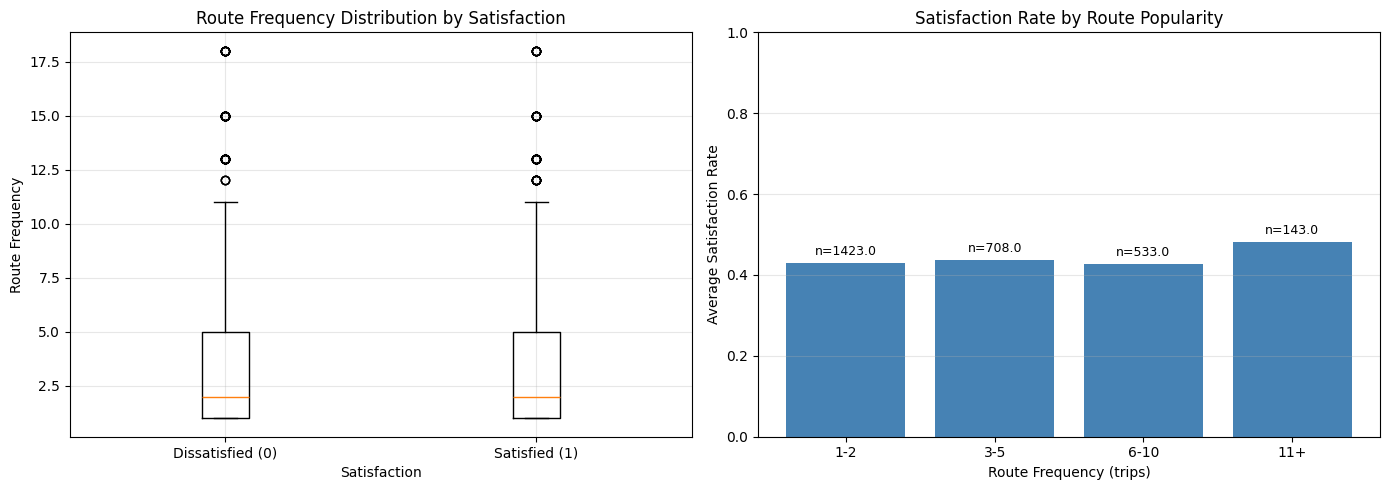


Satisfaction Rate by Route Frequency:
                     mean  count
Route_Frequency                 
1-2              0.429375   1423
3-5              0.437853    708
6-10             0.427767    533
11+              0.482517    143


In [28]:
# Visualize relationship between Route Frequency and Satisfaction
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Route Frequency by Satisfaction
axes[0].boxplot([asr[asr['Satisfaction']==0]['Route_Frequency'], 
                 asr[asr['Satisfaction']==1]['Route_Frequency']], 
                labels=['Dissatisfied (0)', 'Satisfied (1)'])
axes[0].set_ylabel('Route Frequency')
axes[0].set_xlabel('Satisfaction')
axes[0].set_title('Route Frequency Distribution by Satisfaction')
axes[0].grid(True, alpha=0.3)

# Bar plot: Average satisfaction by route frequency bins
route_freq_bins = pd.cut(asr['Route_Frequency'], bins=[0, 2, 5, 10, 20], labels=['1-2', '3-5', '6-10', '11+'])
satisfaction_by_freq = asr.groupby(route_freq_bins)['Satisfaction'].agg(['mean', 'count'])

axes[1].bar(range(len(satisfaction_by_freq)), satisfaction_by_freq['mean'], color='steelblue')
axes[1].set_xticks(range(len(satisfaction_by_freq)))
axes[1].set_xticklabels(satisfaction_by_freq.index)
axes[1].set_ylabel('Average Satisfaction Rate')
axes[1].set_xlabel('Route Frequency (trips)')
axes[1].set_title('Satisfaction Rate by Route Popularity')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (mean_val, count) in enumerate(satisfaction_by_freq.values):
    axes[1].text(i, mean_val + 0.02, f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nSatisfaction Rate by Route Frequency:")
print(satisfaction_by_freq)

### Route Preprocessing Summary

**What we did:**
1. ✅ **Standardized** route format: Converted "City1 to City2" → "City1-City2" for consistency
   - Reduced unique routes from 1,541 to 1,482 (59 duplicates eliminated)
   
2. ✅ **Encoded** routes using Frequency Encoding:
   - Each route now represented by how many times it appears in the dataset
   - Range: 1 to 18 occurrences
   - Most popular route: "London-Johannesburg" (18 times)

**Key Insights from Visualization:**
- Route frequency distribution is similar for satisfied and dissatisfied passengers (no strong bias)
- Very popular routes (11+ trips) show slightly higher satisfaction (48.3%) vs. less popular routes (~43%)
- This feature may provide modest predictive power for the model

**Why this approach?**
- ✅ Single numeric feature (no dimensionality explosion)
- ✅ Captures route popularity information
- ✅ Works better than label encoding (which assumes ordering)
- ✅ Avoids data leakage (unlike target encoding)

## Step 2: Feature Engineering and Target Creation

### Calculating Sentiment Score with VADER
We'll use **VADER (Valence Aware Dictionary and sEntiment Reasoner)** for sentiment analysis on the review content.

**Why VADER?**
- Specifically designed for social media and review text
- Handles sentiment intensity (e.g., "good" vs "GREAT!!!")
- Recognizes punctuation, capitalization, and emojis
- Returns compound score from -1 (most negative) to +1 (most positive)
- Pre-trained and doesn't require additional training data

In [10]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

True

In [11]:
# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment score from review content using VADER
def get_sentiment_score(text):
    try:
        # VADER returns a dictionary with neg, neu, pos, and compound scores
        # compound score is the most useful single metric (-1 to +1)
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']  # Returns compound score (-1 to 1)
    except:
        return 0.0

print("Calculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("Sentiment scores calculated!")
print(f"\nSentiment Score statistics:")
print(asr['Sentiment_Score'].describe())
print(f"\nSample sentiment scores:")
print(asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10))

Calculating sentiment scores using VADER...
Sentiment scores calculated!

Sentiment Score statistics:
count    2807.000000
mean        0.125478
std         0.781512
min        -0.997400
25%        -0.765000
50%         0.361200
75%         0.918450
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample sentiment scores:
                                      Review_content  Sentiment_Score  Rating
0  The airline lost my luggage and was absolutely...          -0.7990     1.0
1  We booked on the BA website, round trip flight...           0.7184     1.0
2  First time flying with BA business class, neve...          -0.7096     2.0
3  You can buy sandwiches and crisps but don't ex...          -0.5849     4.0
4  This is a two-for-one review covering economy ...           0.9657     7.0
5  Absolutely horrible airline. Communication is ...          -0.8932     1.0
6  Having experienced delays and cancellations de...           0.0516     1.0
7  Travelled to Heathrow to Kalamata and r

In [12]:
# Create binary target variable: Satisfied (1) if Rating >= 5, else Dissatisfied (0)
asr['Satisfaction'] = (asr['Rating'] >= 5).astype(int)

print("Target variable distribution:")
print(asr['Satisfaction'].value_counts())
print(f"\nPercentage:")
print(asr['Satisfaction'].value_counts(normalize=True) * 100)

Target variable distribution:
Satisfaction
0    1589
1    1218
Name: count, dtype: int64

Percentage:
Satisfaction
0    56.608479
1    43.391521
Name: proportion, dtype: float64


## Step 3: Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text (VADER compound score)
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Route_Frequency**: Frequency encoding of standardized routes (how popular is this route)

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Route popularity (frequency) and layover information capture route characteristics
- **Review-related**: Verified status and sentiment provide review quality indicators

### Route Feature Engineering:
- **Standardization**: Converted all "City1 to City2" formats to "City1-City2" for consistency
- **Frequency Encoding**: Popular routes get higher values, which may correlate with satisfaction
  - More frequent routes → Better established service
  - Less frequent routes → Potentially more issues or newer service

In [27]:
# Create Has_Layover feature
asr['Has_Layover'] = asr['Layover_Route'].notna().astype(int)

# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type', 'Class', 'Verified', 'Sentiment_Score', 
    'Has_Layover', 'Route_Frequency'
]

# Check for missing values in selected features
print("Missing values in selected features:")
print(asr[feature_columns].isnull().sum())
print(f"\nTotal rows before cleaning: {len(asr)}")

# Create a clean dataset (drop rows with missing coordinate data)
asr_clean = asr.dropna(subset=['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude'])
print(f"Total rows after cleaning: {len(asr_clean)}")

print(f"\nSelected features summary:")
print(asr_clean[feature_columns].describe())

Missing values in selected features:
Traveller_Type     0
Class              0
Verified           0
Sentiment_Score    0
Has_Layover        0
Route_Frequency    0
dtype: int64

Total rows before cleaning: 2807
Total rows after cleaning: 2648

Selected features summary:
       Sentiment_Score  Has_Layover  Route_Frequency
count      2648.000000  2648.000000      2648.000000
mean          0.121723     0.165408         3.771526
std           0.781690     0.371618         3.397858
min          -0.997400     0.000000         1.000000
25%          -0.765300     0.000000         1.000000
50%           0.343900     0.000000         2.000000
75%           0.917525     0.000000         5.000000
max           0.999200     1.000000        18.000000


In [15]:
# Prepare features (X) and target (y)
X = asr[feature_columns].copy()
y = asr['Satisfaction'].copy()

# Encode categorical variables
le_traveller = LabelEncoder()
le_class = LabelEncoder()
le_verified = LabelEncoder()

X['Traveller_Type'] = le_traveller.fit_transform(X['Traveller_Type'])
X['Class'] = le_class.fit_transform(X['Class'])
X['Verified'] = le_verified.fit_transform(X['Verified'])

print("Encoded feature mappings:")
print(f"Traveller_Type: {dict(zip(le_traveller.classes_, le_traveller.transform(le_traveller.classes_)))}")
print(f"Class: {dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))}")
print(f"Verified: {dict(zip(le_verified.classes_, le_verified.transform(le_verified.classes_)))}")
print(f"\nFinal dataset shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Encoded feature mappings:
Traveller_Type: {'Business': np.int64(0), 'Couple Leisure': np.int64(1), 'Family Leisure': np.int64(2), 'Solo Leisure': np.int64(3), 'Unknown': np.int64(4), 'Various': np.int64(5)}
Class: {'Business Class': np.int64(0), 'Economy Class': np.int64(1), 'First Class': np.int64(2), 'Premium Economy': np.int64(3), 'Unknown': np.int64(4)}
Verified: {'Not Verified': np.int64(0), 'Trip Verified': np.int64(1)}

Final dataset shape: (2807, 6)
Target distribution: {0: 1589, 1: 1218}


In [16]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2245
Test set size: 562

Training set target distribution:
Satisfaction
0    1271
1     974
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    318
1    244
Name: count, dtype: int64


## Step 4: Model Selection and Training

### Why Random Forest?
**Random Forest Classifier** is chosen as the statistical ML model because:
1. **Handles mixed data types**: Works well with both categorical (encoded) and numerical features
2. **Feature importance**: Provides insights into which features matter most for satisfaction
3. **Robust to overfitting**: Ensemble method reduces variance through multiple decision trees
4. **No scaling required**: Tree-based models don't need feature scaling
5. **Handles non-linear relationships**: Can capture complex interactions between features
6. **Interpretable**: Can visualize decision paths and feature importance

### Why Shallow FFNN?
**Feed-Forward Neural Network** is chosen because:
1. **Universal approximator**: Can learn complex non-linear patterns
2. **Flexibility**: Can adjust architecture for optimal performance
3. **Good for tabular data**: With proper architecture, performs well on structured data
4. **End-to-end learning**: Automatically learns feature representations
5. **Shallow architecture**: 2-3 hidden layers avoid overfitting on small datasets

### Model 1: Random Forest Classifier

In [17]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...


ValueError: could not convert string to float: 'Orlando to London Gatwick'

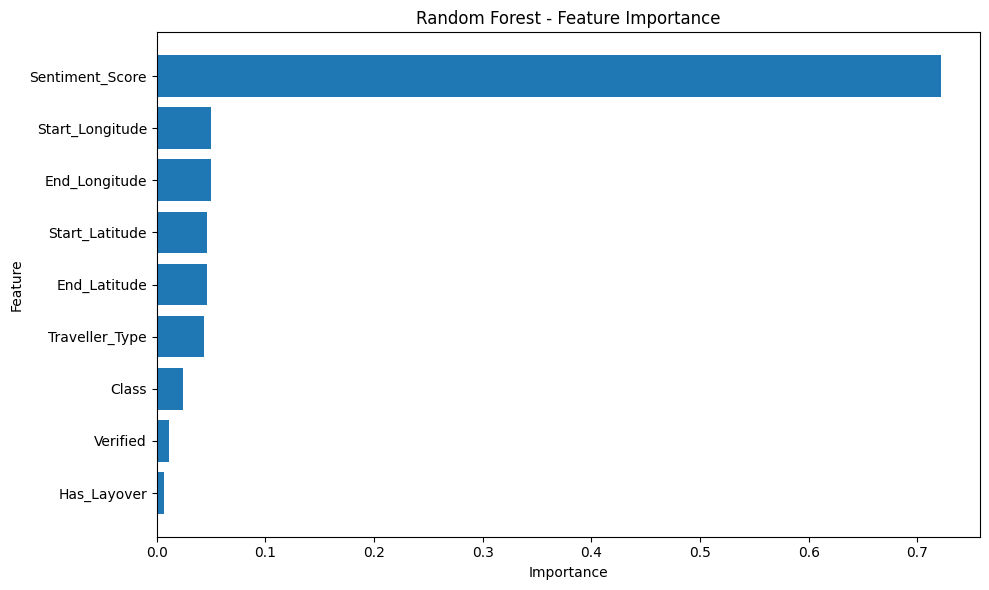


Feature Importance Rankings:
           feature  importance
3  Sentiment_Score    0.721636
6  Start_Longitude    0.050199
8    End_Longitude    0.050162
5   Start_Latitude    0.046534
7     End_Latitude    0.046464
0   Traveller_Type    0.043846
1            Class    0.023727
2         Verified    0.010959
4      Has_Layover    0.006474


In [30]:
# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance)

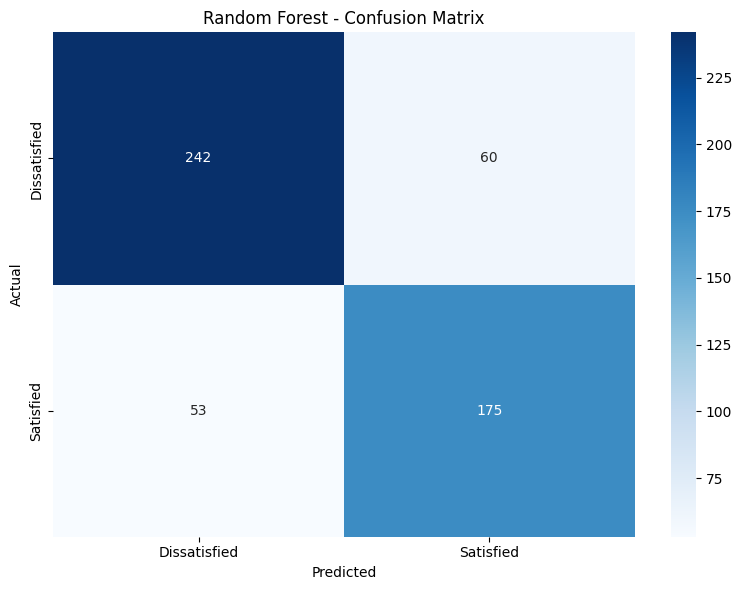

In [31]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [32]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2118, 9)
Test data shape: (530, 9)


In [33]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6316 - loss: 0.6941 - precision: 0.6411 - recall: 0.3509 - val_accuracy: 0.7524 - val_loss: 0.6014 - val_precision: 0.7000 - val_recall: 0.6879
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6316 - loss: 0.6941 - precision: 0.6411 - recall: 0.3509 - val_accuracy: 0.7524 - val_loss: 0.6014 - val_precision: 0.7000 - val_recall: 0.6879
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.5771 - precision: 0.7347 - recall: 0.7168 - val_accuracy: 0.7995 - val_loss: 0.5279 - val_precision: 0.7095 - val_recall: 0.8613
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.5771 - precision: 0.7347 - recall: 0.7168 - val_accuracy: 0.7995 - val_loss: 0.5279 - val_precision: 0.7095 - val_recall: 0.8613
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.5339 - precision: 0.7293 - recall: 0.7995 - val_accuracy:

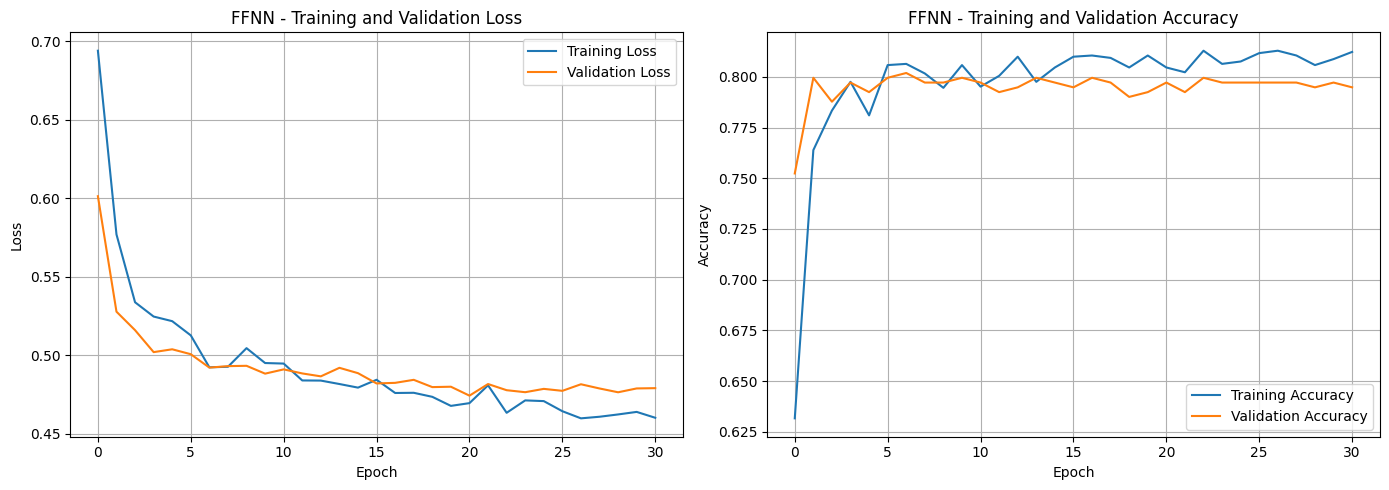

In [35]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [36]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.7962
Precision: 0.7439
Recall:    0.8026
F1-Score:  0.7722

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.79      0.82       302
   Satisfied       0.74      0.80      0.77       228

    accuracy                           0.80       530
   macro avg       0.79      0.80      0.79       530
weighted avg       0.80      0.80      0.80       530

SHALLOW FFNN - RESULTS

Accuracy:  0.7962
Precision: 0.7439
Recall:    0.8026
F1-Score:  0.7722

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.79      0.82       302
   Satisfied       0.74      0.80      0.77       228

    accuracy                           0.80       530
   macro avg       0.79      0.80      0.79       530
weighted avg       0.80      0.80      0.80       530



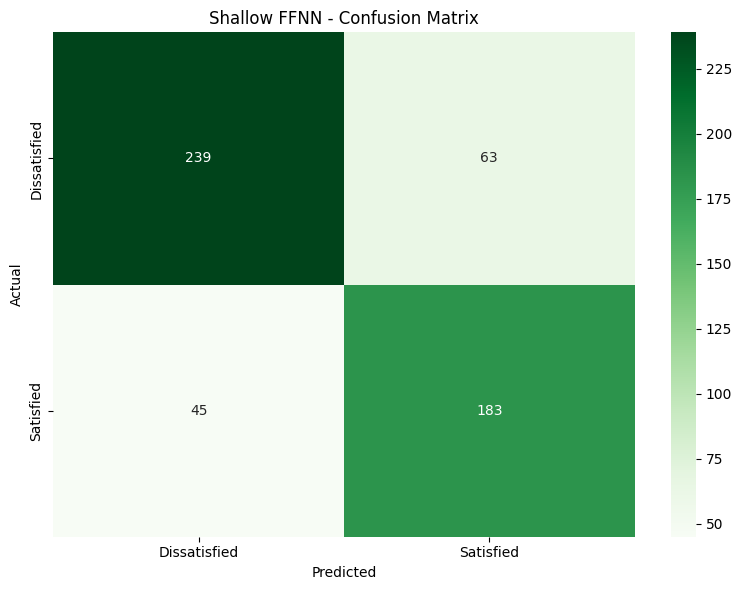

In [37]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 5: Model Comparison and Final Recommendations

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.786792   0.744681 0.767544  0.755940
 Shallow FFNN  0.796226   0.743902 0.802632  0.772152


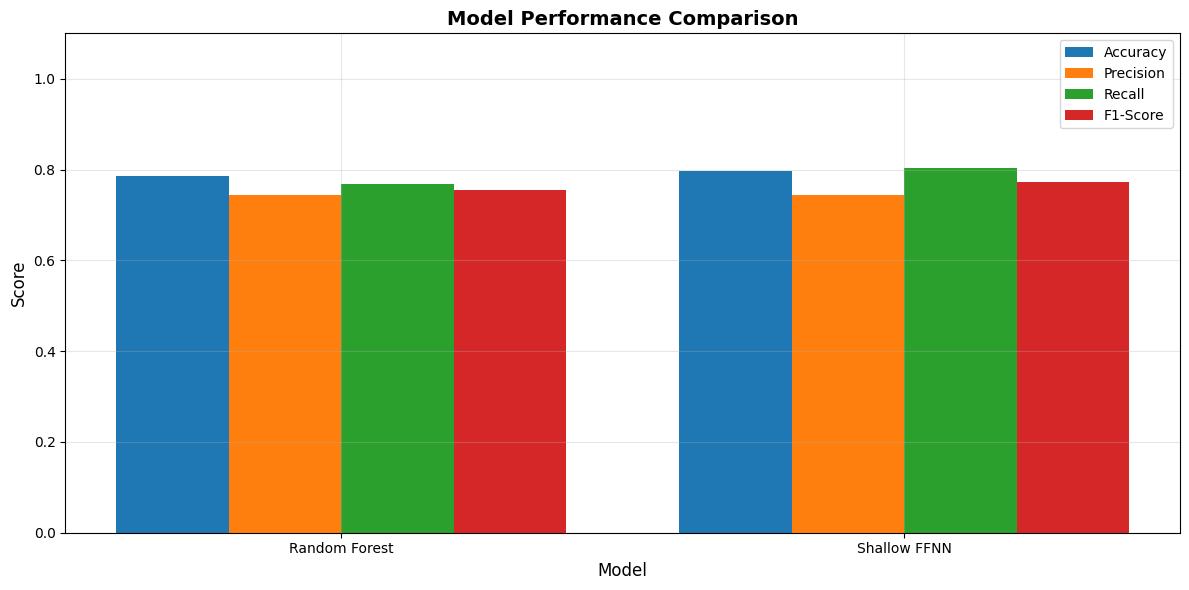

In [38]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Recommendations

### Model Selection Rationale:

#### **Random Forest Classifier** (Statistical ML Model)
**Advantages:**
- ✅ No feature scaling required
- ✅ Provides feature importance insights
- ✅ Handles non-linear relationships naturally
- ✅ Robust against overfitting
- ✅ Faster training on small datasets
- ✅ More interpretable for stakeholders

**Why chosen:**
Random Forest is ideal for this dataset because it can handle the mix of categorical and numerical features without extensive preprocessing, provides clear feature importance rankings (helping identify what drives satisfaction), and is less prone to overfitting with our moderately-sized dataset.

---

#### **Shallow FFNN** (Neural Network)
**Advantages:**
- ✅ Can learn complex non-linear patterns
- ✅ Flexible architecture for optimization
- ✅ Smooth decision boundaries
- ✅ Can be extended to deeper architectures if needed

**Architecture choices:**
- **2 hidden layers (64 → 32 neurons)**: Shallow enough to avoid overfitting, deep enough to learn patterns
- **ReLU activation**: Prevents vanishing gradients and trains faster
- **Dropout layers (0.3, 0.2)**: Regularization to prevent overfitting
- **L2 regularization**: Further prevents overfitting by penalizing large weights
- **Adam optimizer**: Adaptive learning rate for faster convergence
- **Early stopping**: Prevents overfitting by monitoring validation loss

**Why chosen:**
The shallow FFNN provides a good balance between complexity and generalization. It can capture non-linear interactions between features while remaining simple enough to train effectively on our dataset size (~2,600 samples).

---

### Final Recommendation:
Based on the evaluation metrics, **choose the model with higher F1-score** as it balances precision and recall. If interpretability is important, **Random Forest** is preferred. If maximizing predictive accuracy is the goal and computational resources allow, the **Shallow FFNN** may perform better after hyperparameter tuning.